# CHC (CHIRPS) — daily rainfall quickstart (live)

Download a few days of **CHIRPS-2.0 daily precipitation** for a small area over Colombia, then read and plot the cropped GeoTIFF. CHC uses **anonymous FTP**, so no credentials are needed.

> This notebook performs a real network download from `data.chc.ucsb.edu`.

In [1]:
import tempfile

from loguru import logger

from earthlens import EarthLens

logger.disable('earthlens')  # quieten the download logs for a clean notebook

lens = EarthLens(
    data_source='chc',
    temporal_resolution='daily',
    start='2009-01-01',
    end='2009-01-03',
    variables=['precipitation'],
    lat_lim=[4.19, 4.64],
    lon_lim=[-75.65, -74.73],
    path=tempfile.mkdtemp(prefix='chirps_'),
)
paths = lens.download(progress_bar=False)  # returns the written GeoTIFF paths
print(f'{len(paths)} files written')

2026-06-07 18:04:16 | INFO | pyramids.base.config | Logging is configured.


3 files written


The backend fetches each global daily tile and crops it to the requested bbox, writing one `global-daily_precipitation_<date>.tif` per day.

In [2]:
for p in sorted(paths):
    print(p.name)

global-daily_precipitation_2009.01.01.tif
global-daily_precipitation_2009.01.02.tif
global-daily_precipitation_2009.01.03.tif


## Read and plot the cropped raster

EPSG 4326 | shape (10, 20)


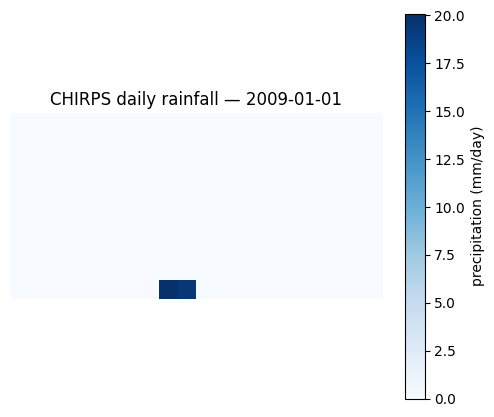

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

ds = Dataset.read_file(str(sorted(paths)[0]))
arr = np.asarray(ds.read_array(), dtype='float32')
arr = arr[0] if arr.ndim == 3 else arr
arr = np.where(arr < 0, np.nan, arr)  # CHIRPS no-data is -9999
print('EPSG', ds.epsg, '| shape', arr.shape)

plt.figure(figsize=(6, 5))
plt.imshow(arr, cmap='Blues')
plt.colorbar(label='precipitation (mm/day)')
plt.title('CHIRPS daily rainfall — 2009-01-01')
plt.axis('off')
plt.show()